# Phase 1: Power Plant Steam Turbine Optimization (var1)
## BT2024195 — Polynomial Regression Assignment (Improved: ElasticNet)

**Objective:** Predict the **Net Power Score (y)** from 6 operational parameters using polynomial regression.

**Features:** x1–x6 (valve, coolant, pump pressure, blade pitch, gas exhaust, steam inlet)  
**Target:** y = Net Power Score (polynomial up to degree 10)

**Improvement over baseline:**
- ElasticNet regularization: automatically balances Ridge (L2) and Lasso (L1)
- Fine alpha search via `np.logspace` (100 values instead of 7)
- Grid search over `l1_ratio` — lets CV decide whether to use Ridge, Lasso, or a blend
- 10-fold CV for more reliable estimates

## Step 1: Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge, ElasticNet
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print('Libraries imported successfully!')

Libraries imported successfully!


## Step 2: Load and Explore the Datasets

In [2]:
train_df = pd.read_csv('../data/BT2024195_train_var1.csv')
test_df  = pd.read_csv('../data/BT2024195_test_var1.csv')

print(f'Train shape: {train_df.shape}')
print(f'Test shape:  {test_df.shape}')
print(f'Columns:     {list(train_df.columns)}')

Train shape: (1000, 7)
Test shape:  (1000, 6)
Columns:     ['x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'y']


In [3]:
print('=== Training Data — First 5 rows ===')
display(train_df.head())
print('\n=== Descriptive Statistics ===')
display(train_df.describe())

=== Training Data — First 5 rows ===


,x1,x2,x3,x4,x5,x6,y
0,-1.000000,-0.454191,0.696655,-1.000000,0.875778,0.436210,-0.439777
1,0.428209,-1.000000,0.344337,-1.000000,-0.361014,-1.000000,9.998931
2,0.054421,-0.777555,-1.000000,0.982571,0.600547,0.365162,-0.675755
3,0.615354,1.000000,1.000000,0.834751,1.000000,0.926931,-7.203895
4,-0.912429,-0.259165,-0.597190,-1.000000,0.863821,0.382314,2.706250



=== Descriptive Statistics ===


,x1,x2,x3,x4,x5,x6,y
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,-0.038363,-0.040695,-0.014783,-0.010135,-0.043422,-0.015705,0.873591
std,0.715971,0.711731,0.707186,0.721040,0.712061,0.722158,3.270752
min,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-10.727085
25%,-0.722506,-0.754655,-0.677927,-0.686135,-0.707499,-0.720350,-1.090142
50%,-0.036354,-0.036706,0.000610,-0.014369,-0.056209,-0.042578,0.728689
75%,0.619751,0.580794,0.622187,0.671293,0.592740,0.687605,3.016630
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,11.339238


In [4]:
print('Missing values — Train:')
print(train_df.isnull().sum())
print('\nMissing values — Test:')
print(test_df.isnull().sum())

Missing values — Train:
x1    0
x2    0
x3    0
x4    0
x5    0
x6    0
y     0
dtype: int64

Missing values — Test:
x1    0
x2    0
x3    0
x4    0
x5    0
x6    0
dtype: int64


## Step 3: Exploratory Data Analysis (EDA)

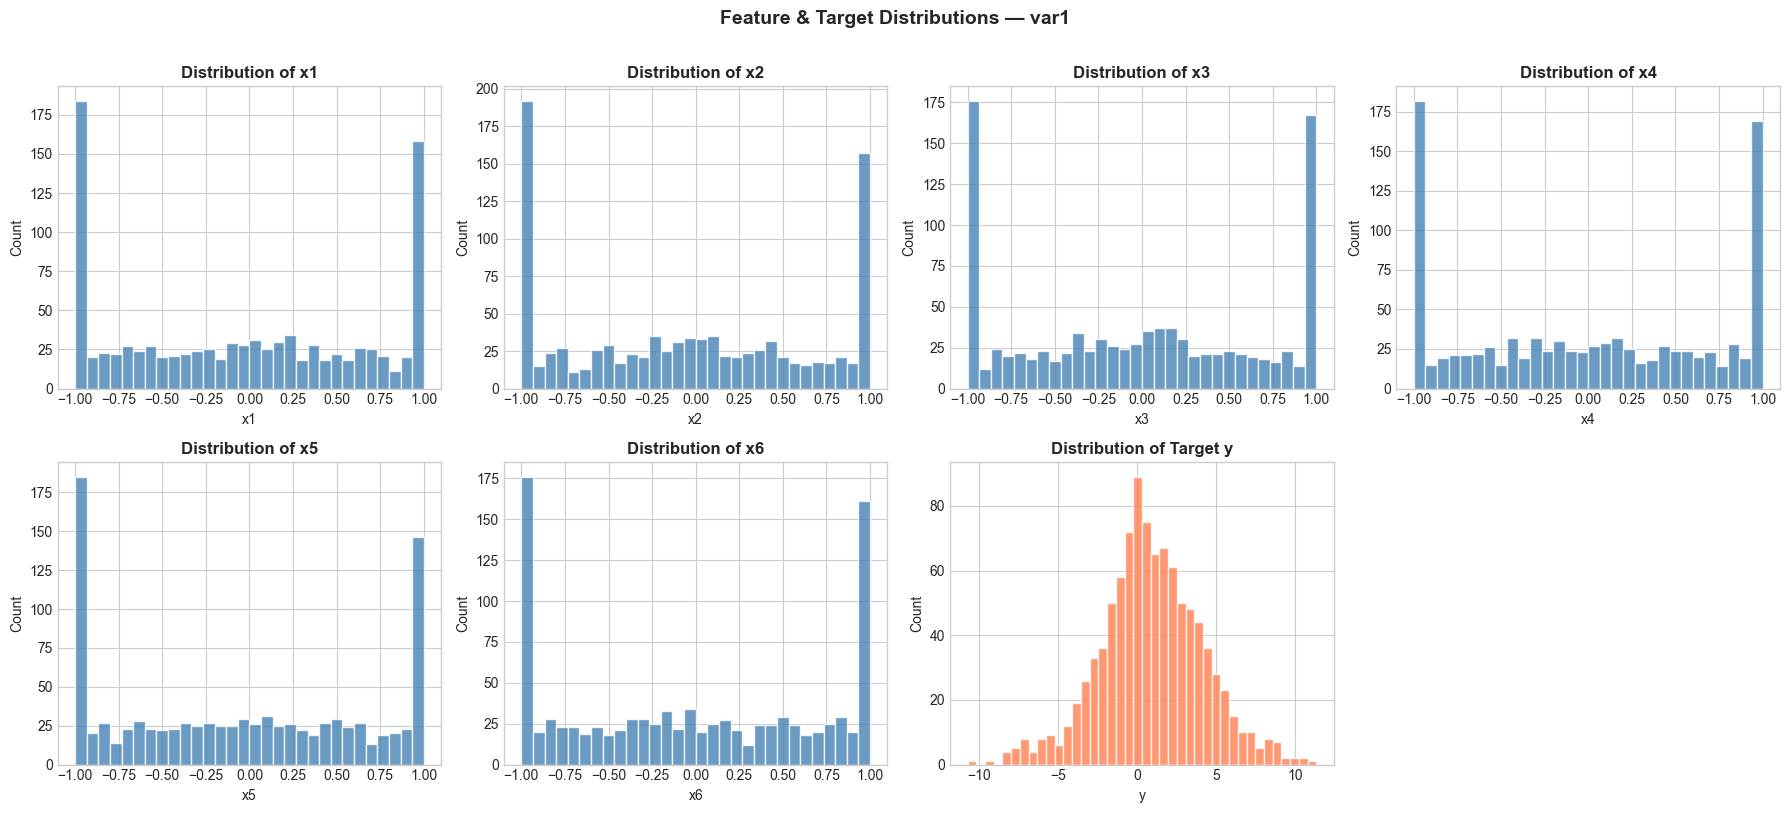

In [5]:
feature_cols = ['x1', 'x2', 'x3', 'x4', 'x5', 'x6']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(feature_cols):
    axes[i].hist(train_df[col], bins=30, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(f'Distribution of {col}', fontweight='bold')
    axes[i].set_xlabel(col); axes[i].set_ylabel('Count')
axes[6].hist(train_df['y'], bins=40, color='coral', edgecolor='white', alpha=0.8)
axes[6].set_title('Distribution of Target y', fontweight='bold')
axes[6].set_xlabel('y'); axes[6].set_ylabel('Count')
axes[7].set_visible(False)
plt.suptitle('Feature & Target Distributions — var1', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../images/var1_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

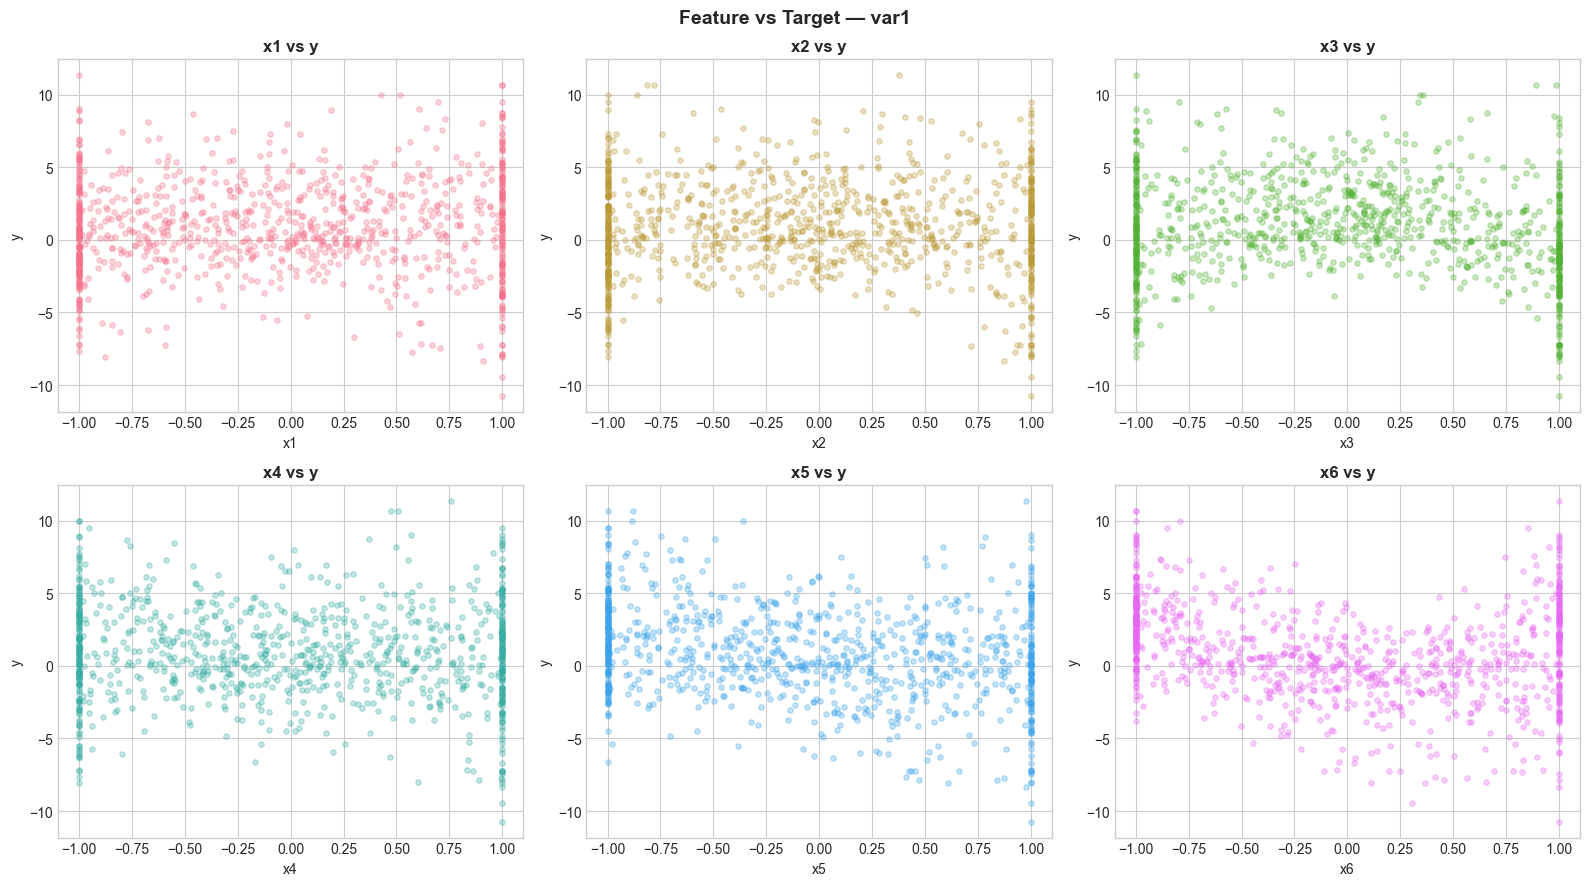

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
colors = sns.color_palette('husl', 6)
for i, col in enumerate(feature_cols):
    axes[i].scatter(train_df[col], train_df['y'], alpha=0.3, color=colors[i], s=15)
    axes[i].set_xlabel(col); axes[i].set_ylabel('y')
    axes[i].set_title(f'{col} vs y', fontweight='bold')
plt.suptitle('Feature vs Target — var1', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/var1_scatter_plots.png', dpi=150, bbox_inches='tight')
plt.show()

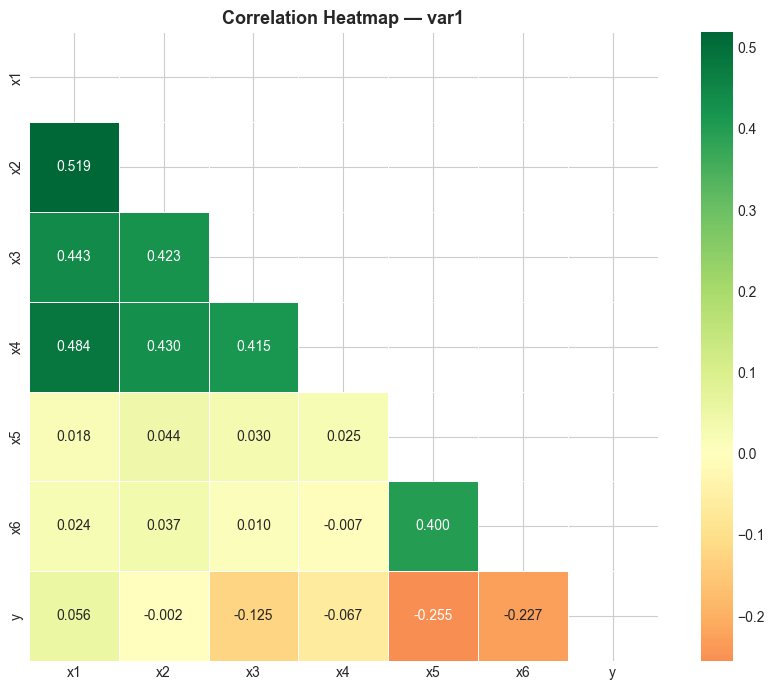

In [7]:
fig, ax = plt.subplots(figsize=(9, 7))
corr = train_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdYlGn', center=0,
            linewidths=0.5, ax=ax, mask=mask, square=True)
ax.set_title('Correlation Heatmap — var1', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/var1_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 4: Prepare Features and Labels

In [8]:
X_train = train_df[feature_cols].values
y_train = train_df['y'].values
X_test  = test_df[feature_cols].values

print(f'X_train: {X_train.shape}, y_train: {y_train.shape}, X_test: {X_test.shape}')

X_train: (1000, 6), y_train: (1000,), X_test: (1000, 6)


## Step 5: Degree Selection via 10-Fold Cross-Validation

We use Ridge(alpha=1.0) here as a fast proxy to select the best polynomial degree.  
Ridge is used for degree selection only because ElasticNet with grid search over (alpha, l1_ratio) for each degree would be computationally expensive. Once the optimal degree is identified, we do a full hyperparameter search with ElasticNet.

In [9]:
degrees = list(range(1, 11))
cv_mse_means, cv_mse_stds, cv_r2_means = [], [], []

kf = KFold(n_splits=10, shuffle=True, random_state=42)  # 10-fold for better estimate

print(f"{'Degree':>6} | {'CV MSE (mean)':>15} | {'CV MSE (std)':>13} | {'CV R2 (mean)':>13}")
print('-' * 60)

for deg in degrees:
    pipe = Pipeline([
        ('poly',   PolynomialFeatures(degree=deg, include_bias=False)),
        ('scaler', StandardScaler()),
        ('model',  Ridge(alpha=1.0))
    ])
    mse_scores = -cross_val_score(pipe, X_train, y_train, cv=kf, scoring='neg_mean_squared_error')
    r2_scores  =  cross_val_score(pipe, X_train, y_train, cv=kf, scoring='r2')
    cv_mse_means.append(mse_scores.mean())
    cv_mse_stds.append(mse_scores.std())
    cv_r2_means.append(r2_scores.mean())
    print(f"{deg:>6} | {mse_scores.mean():>15.4f} | {mse_scores.std():>13.4f} | {r2_scores.mean():>13.4f}")

best_deg_r2  = degrees[np.argmax(cv_r2_means)]
best_deg_mse = degrees[np.argmin(cv_mse_means)]
print(f'\nBest degree by R²:  {best_deg_r2}')
print(f'Best degree by MSE: {best_deg_mse}')

Degree |   CV MSE (mean) |  CV MSE (std) |  CV R2 (mean)
------------------------------------------------------------
     1 |          9.5474 |        1.6085 |        0.0990
     2 |          3.0386 |        0.4630 |        0.7075
     3 |          0.9651 |        0.1267 |        0.9069
     4 |          0.6927 |        0.0759 |        0.9335
     5 |          0.6731 |        0.1352 |        0.9356
     6 |          1.2581 |        0.2843 |        0.8808
     7 |          1.4922 |        0.3639 |        0.8577
     8 |          1.9980 |        0.5513 |        0.8084
     9 |          2.2938 |        0.7008 |        0.7828
    10 |          2.6839 |        0.7279 |        0.7438

Best degree by R²:  5
Best degree by MSE: 5


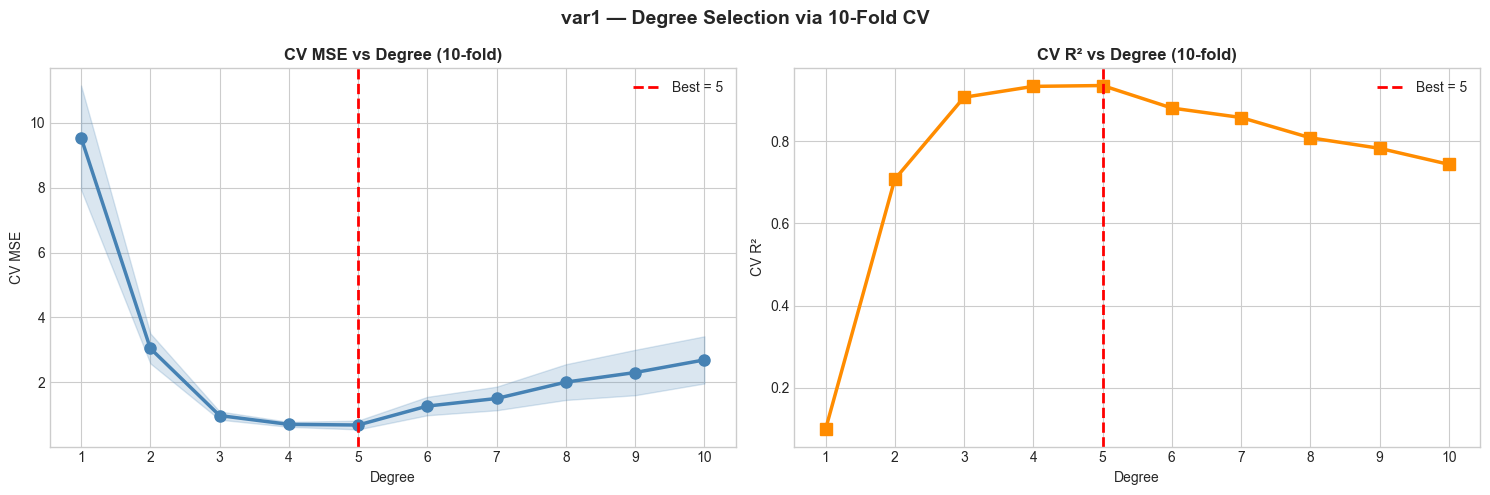

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot(degrees, cv_mse_means, 'o-', color='steelblue', lw=2.5, ms=8)
axes[0].fill_between(degrees,
                      np.array(cv_mse_means) - np.array(cv_mse_stds),
                      np.array(cv_mse_means) + np.array(cv_mse_stds),
                      alpha=0.2, color='steelblue')
axes[0].axvline(best_deg_mse, color='red', ls='--', lw=2, label=f'Best = {best_deg_mse}')
axes[0].set_title('CV MSE vs Degree (10-fold)', fontweight='bold')
axes[0].set_xlabel('Degree'); axes[0].set_ylabel('CV MSE')
axes[0].legend(); axes[0].set_xticks(degrees)

axes[1].plot(degrees, cv_r2_means, 's-', color='darkorange', lw=2.5, ms=8)
axes[1].axvline(best_deg_r2, color='red', ls='--', lw=2, label=f'Best = {best_deg_r2}')
axes[1].set_title('CV R² vs Degree (10-fold)', fontweight='bold')
axes[1].set_xlabel('Degree'); axes[1].set_ylabel('CV R²')
axes[1].legend(); axes[1].set_xticks(degrees)

plt.suptitle('var1 — Degree Selection via 10-Fold CV', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/var1_degree_selection.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 6: ElasticNet Hyperparameter Search (alpha × l1_ratio)

ElasticNet combines Ridge (L2) and Lasso (L1) regularization:
$$\text{ElasticNet Loss} = \text{MSE} + \alpha \cdot \left[\text{l1\_ratio} \cdot |\beta|_1 + \frac{1-\text{l1\_ratio}}{2} \cdot |\beta|_2^2\right]$$

- `l1_ratio = 0` → pure Ridge (keeps all features, shrinks coefficients)
- `l1_ratio = 1` → pure Lasso (zeros out irrelevant polynomial terms)
- `0 < l1_ratio < 1` → hybrid; cross-validation will find the best mix

We search `alpha` over 50 log-spaced values and `l1_ratio` over 9 candidate values.

In [11]:
best_degree = best_deg_r2
print(f'Selected degree: {best_degree}')

alphas     = np.logspace(-4, 4, 50)              # 50 fine-grained alpha values
l1_ratios  = [0.0, 0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99, 1.0]  # 0=Ridge ... 1=Lasso

best_r2    = -np.inf
best_alpha = None
best_l1    = None
results    = []

print(f"\nSearching {len(alphas)} alphas × {len(l1_ratios)} l1_ratios = {len(alphas)*len(l1_ratios)} combinations...")

for l1 in l1_ratios:
    for alpha in alphas:
        pipe = Pipeline([
            ('poly',   PolynomialFeatures(degree=best_degree, include_bias=False)),
            ('scaler', StandardScaler()),
            ('model',  ElasticNet(alpha=alpha, l1_ratio=l1, max_iter=10000, random_state=42))
        ])
        r2_scores = cross_val_score(pipe, X_train, y_train, cv=kf, scoring='r2')
        mean_r2   = r2_scores.mean()
        results.append({'alpha': alpha, 'l1_ratio': l1, 'cv_r2': mean_r2})
        if mean_r2 > best_r2:
            best_r2    = mean_r2
            best_alpha = alpha
            best_l1    = l1

results_df = pd.DataFrame(results)
print(f'\nBest alpha   : {best_alpha:.6f}')
print(f'Best l1_ratio: {best_l1}  (0=Ridge, 1=Lasso)')
print(f'Best CV R²   : {best_r2:.6f}')

Selected degree: 5

Searching 50 alphas × 9 l1_ratios = 450 combinations...

Best alpha   : 0.009103
Best l1_ratio: 1.0  (0=Ridge, 1=Lasso)
Best CV R²   : 0.971316


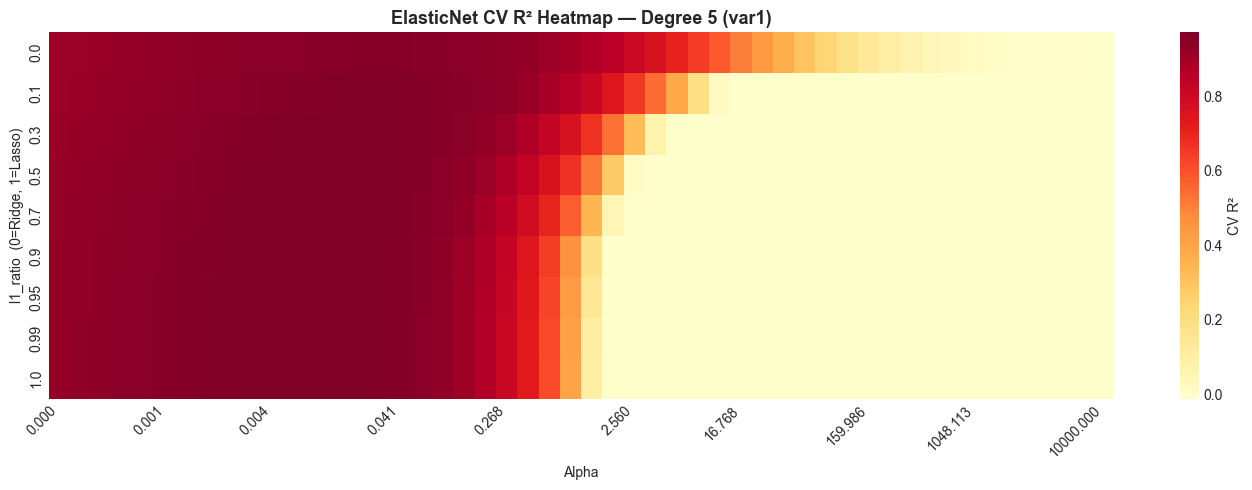

In [12]:
# Heatmap: CV R² across alpha × l1_ratio
pivot = results_df.pivot(index='l1_ratio', columns='alpha', values='cv_r2')

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(pivot, cmap='YlOrRd', ax=ax, cbar_kws={'label': 'CV R²'})
ax.set_title(f'ElasticNet CV R² Heatmap — Degree {best_degree} (var1)', fontsize=13, fontweight='bold')
ax.set_xlabel('Alpha')
ax.set_ylabel('l1_ratio  (0=Ridge, 1=Lasso)')
# Only show a subset of alpha tick labels for readability
n_ticks = 10
tick_pos = np.linspace(0, len(alphas)-1, n_ticks, dtype=int)
ax.set_xticks(tick_pos + 0.5)
ax.set_xticklabels([f'{alphas[i]:.3f}' for i in tick_pos], rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../images/var1_elasticnet_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

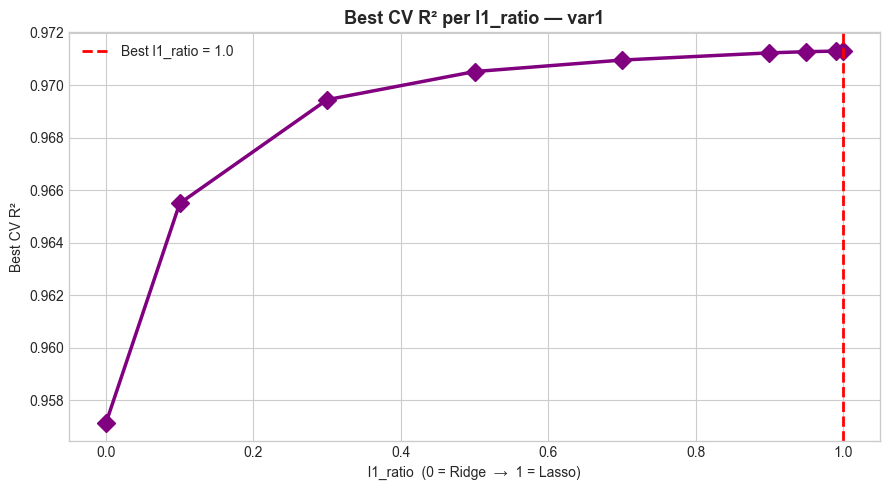


Best CV R² per l1_ratio:
 l1_ratio    cv_r2
     0.00 0.957134
     0.10 0.965505
     0.30 0.969457
     0.50 0.970528
     0.70 0.970968
     0.90 0.971242
     0.95 0.971287
     0.99 0.971310
     1.00 0.971316


In [13]:
# Best CV R² per l1_ratio (to see Ridge vs Lasso vs blend preference)
best_per_l1 = results_df.groupby('l1_ratio')['cv_r2'].max().reset_index()
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(best_per_l1['l1_ratio'], best_per_l1['cv_r2'], 'D-', color='purple', lw=2.5, ms=9)
ax.axvline(best_l1, color='red', ls='--', lw=2, label=f'Best l1_ratio = {best_l1}')
ax.set_title('Best CV R² per l1_ratio — var1', fontsize=13, fontweight='bold')
ax.set_xlabel('l1_ratio  (0 = Ridge  →  1 = Lasso)')
ax.set_ylabel('Best CV R²')
ax.legend()
plt.tight_layout()
plt.savefig('../images/var1_l1ratio_search.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nBest CV R² per l1_ratio:')
print(best_per_l1.to_string(index=False))

## Step 7: Train Final Model with Best (degree, alpha, l1_ratio)

In [14]:
final_pipe = Pipeline([
    ('poly',   PolynomialFeatures(degree=best_degree, include_bias=False)),
    ('scaler', StandardScaler()),
    ('model',  ElasticNet(alpha=best_alpha, l1_ratio=best_l1, max_iter=10000, random_state=42))
])
final_pipe.fit(X_train, y_train)
y_pred_train = final_pipe.predict(X_train)

train_mse  = mean_squared_error(y_train, y_pred_train)
train_r2   = r2_score(y_train, y_pred_train)
n_features = final_pipe.named_steps['poly'].n_output_features_

# Count how many coefficients ElasticNet zeroed out (Lasso effect)
coefs      = final_pipe.named_steps['model'].coef_
n_zero     = np.sum(coefs == 0)
n_nonzero  = np.sum(coefs != 0)

print('=== Final Model ===')
print(f'Degree           : {best_degree}')
print(f'Alpha            : {best_alpha:.6f}')
print(f'l1_ratio         : {best_l1}  (0=Ridge, 1=Lasso)')
print(f'Poly features    : {n_features}')
print(f'Non-zero coefs   : {n_nonzero}  ({n_nonzero/n_features*100:.1f}%)')
print(f'Zeroed-out coefs : {n_zero}  ({n_zero/n_features*100:.1f}%)')
print(f'Train MSE        : {train_mse:.6f}')
print(f'Train R²         : {train_r2:.6f}')

=== Final Model ===
Degree           : 5
Alpha            : 0.009103
l1_ratio         : 1.0  (0=Ridge, 1=Lasso)
Poly features    : 461
Non-zero coefs   : 126  (27.3%)
Zeroed-out coefs : 335  (72.7%)
Train MSE        : 0.216335
Train R²         : 0.979757


## Step 8: Residual Analysis

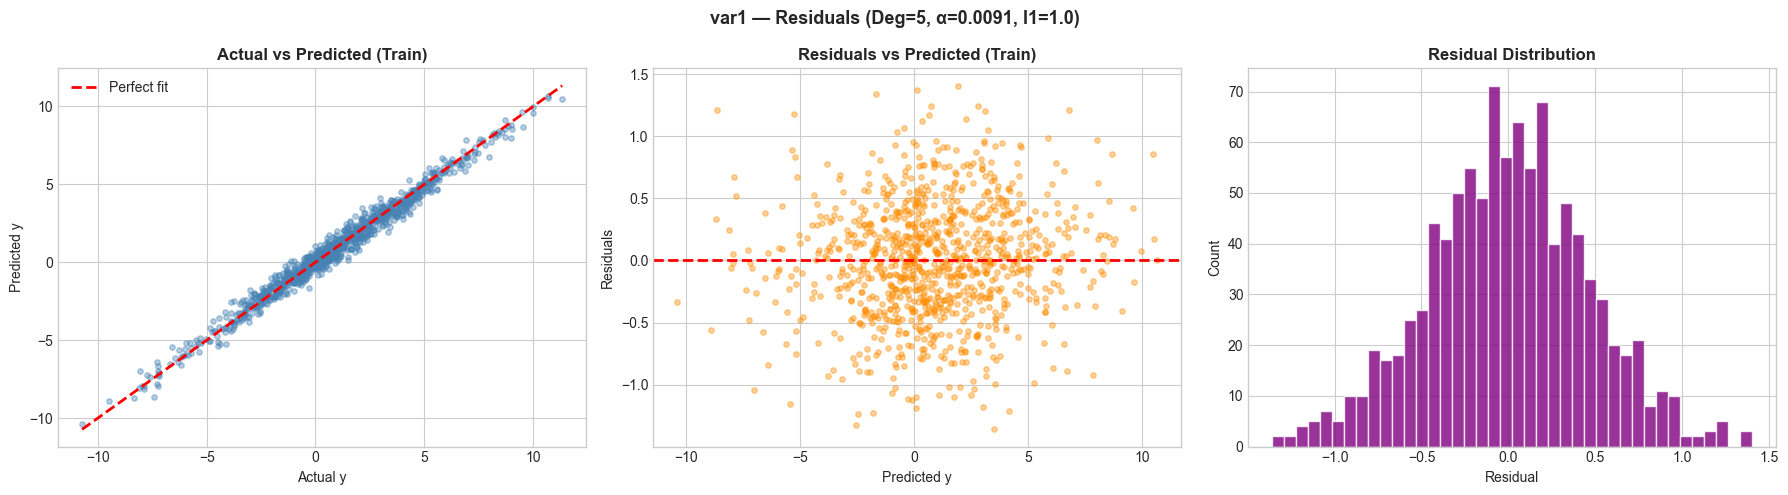

Residual mean: -0.000000  |  std: 0.465118


In [15]:
residuals = y_train - y_pred_train

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
lo = min(y_train.min(), y_pred_train.min())
hi = max(y_train.max(), y_pred_train.max())

axes[0].scatter(y_train, y_pred_train, alpha=0.4, color='steelblue', s=15)
axes[0].plot([lo, hi], [lo, hi], 'r--', lw=2, label='Perfect fit')
axes[0].set_title('Actual vs Predicted (Train)', fontweight='bold')
axes[0].set_xlabel('Actual y'); axes[0].set_ylabel('Predicted y'); axes[0].legend()

axes[1].scatter(y_pred_train, residuals, alpha=0.4, color='darkorange', s=15)
axes[1].axhline(0, color='red', ls='--', lw=2)
axes[1].set_title('Residuals vs Predicted (Train)', fontweight='bold')
axes[1].set_xlabel('Predicted y'); axes[1].set_ylabel('Residuals')

axes[2].hist(residuals, bins=40, color='purple', edgecolor='white', alpha=0.8)
axes[2].set_title('Residual Distribution', fontweight='bold')
axes[2].set_xlabel('Residual'); axes[2].set_ylabel('Count')

plt.suptitle(f'var1 — Residuals (Deg={best_degree}, α={best_alpha:.4f}, l1={best_l1})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/var1_residuals.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Residual mean: {residuals.mean():.6f}  |  std: {residuals.std():.6f}')

## Step 9: Cross-Validation Summary of Final Model

In [16]:
cv_mse_final = -cross_val_score(final_pipe, X_train, y_train, cv=kf, scoring='neg_mean_squared_error')
cv_r2_final  =  cross_val_score(final_pipe, X_train, y_train, cv=kf, scoring='r2')

print('=== Final ElasticNet Model — 10-Fold CV ===')
print(f'CV MSE: {cv_mse_final.mean():.6f} +/- {cv_mse_final.std():.6f}')
print(f'CV R²:  {cv_r2_final.mean():.6f} +/- {cv_r2_final.std():.6f}')
print()
for i, (m, r) in enumerate(zip(cv_mse_final, cv_r2_final), 1):
    print(f'  Fold {i:2d}: MSE = {m:.6f}, R² = {r:.6f}')

=== Final ElasticNet Model — 10-Fold CV ===
CV MSE: 0.297031 +/- 0.023987
CV R²:  0.971316 +/- 0.004937

  Fold  1: MSE = 0.289759, R² = 0.970272
  Fold  2: MSE = 0.300348, R² = 0.973139
  Fold  3: MSE = 0.322453, R² = 0.959248
  Fold  4: MSE = 0.314960, R² = 0.971146
  Fold  5: MSE = 0.284650, R² = 0.980130
  Fold  6: MSE = 0.286022, R² = 0.971678
  Fold  7: MSE = 0.243541, R² = 0.974461
  Fold  8: MSE = 0.318716, R² = 0.970792
  Fold  9: MSE = 0.327192, R² = 0.969467
  Fold 10: MSE = 0.282663, R² = 0.972826


## Step 10: Coefficient Analysis (ElasticNet Sparsity)

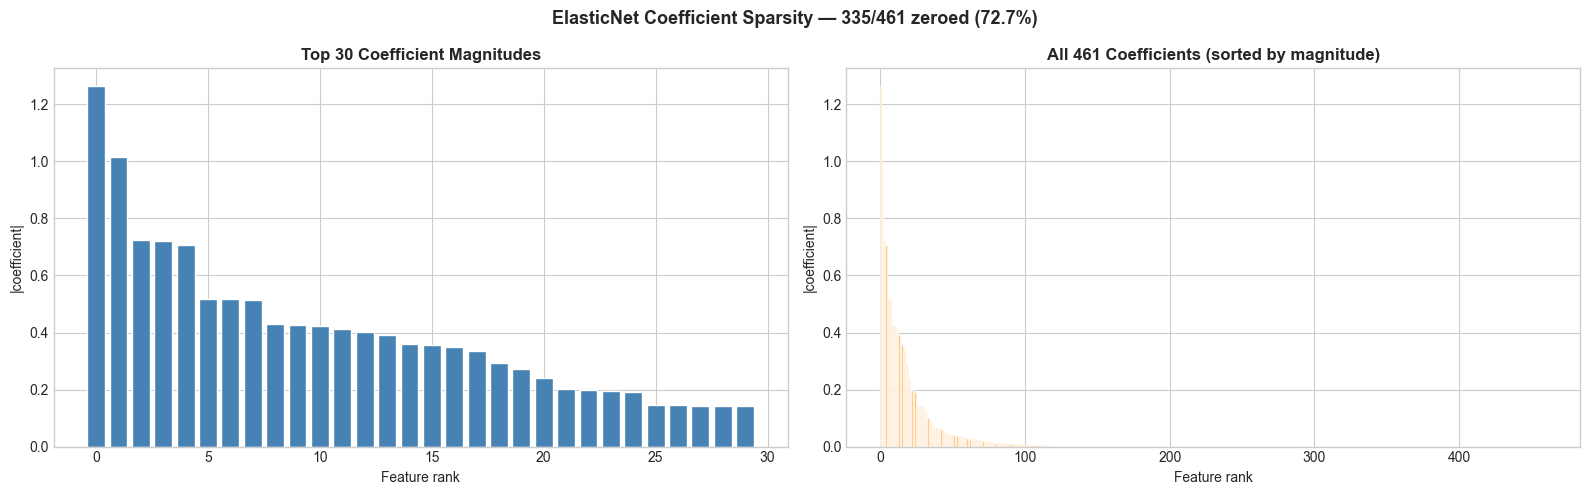

In [17]:
# Visualize the coefficient magnitudes (ElasticNet sparsity)
coef_abs = np.abs(coefs)
sorted_idx = np.argsort(coef_abs)[::-1]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Top 30 coefficients
top_n = min(30, n_nonzero)
axes[0].bar(range(top_n), coef_abs[sorted_idx[:top_n]], color='steelblue', edgecolor='white')
axes[0].set_title(f'Top {top_n} Coefficient Magnitudes', fontweight='bold')
axes[0].set_xlabel('Feature rank'); axes[0].set_ylabel('|coefficient|')

# All coefficients
axes[1].bar(range(n_features), coef_abs[sorted_idx], color='darkorange', edgecolor='white', alpha=0.7)
axes[1].axhline(0, color='black', lw=0.5)
axes[1].set_title(f'All {n_features} Coefficients (sorted by magnitude)', fontweight='bold')
axes[1].set_xlabel('Feature rank'); axes[1].set_ylabel('|coefficient|')

plt.suptitle(f'ElasticNet Coefficient Sparsity — {n_zero}/{n_features} zeroed ({n_zero/n_features*100:.1f}%)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/var1_coeff_sparsity.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 11: Generate Test Predictions

Test predictions shape: (1000,)
Min: -10.4254, Max: 16.2019
Mean: 1.2645, Std: 4.1718


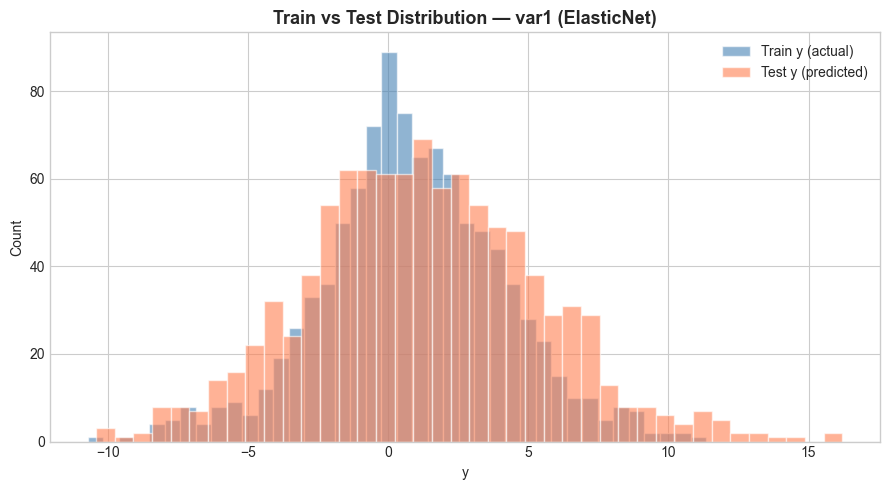

In [18]:
y_pred_test = final_pipe.predict(X_test)

print(f'Test predictions shape: {y_pred_test.shape}')
print(f'Min: {y_pred_test.min():.4f}, Max: {y_pred_test.max():.4f}')
print(f'Mean: {y_pred_test.mean():.4f}, Std: {y_pred_test.std():.4f}')

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(y_train, bins=40, alpha=0.6, color='steelblue', label='Train y (actual)', edgecolor='white')
ax.hist(y_pred_test, bins=40, alpha=0.6, color='coral', label='Test y (predicted)', edgecolor='white')
ax.set_title('Train vs Test Distribution — var1 (ElasticNet)', fontsize=13, fontweight='bold')
ax.set_xlabel('y'); ax.set_ylabel('Count'); ax.legend()
plt.tight_layout()
plt.savefig('../images/var1_pred_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 12: Save Submission File

In [19]:
submission = pd.DataFrame({'y': y_pred_test})
submission.to_csv('../predictions/BT2024195_pred_var1.csv', index=False)
print('Saved: BT2024195_pred_var1.csv')
print(f'Shape: {submission.shape}')
display(submission.head(10))

Saved: BT2024195_pred_var1.csv
Shape: (1000, 1)


,y
0,-6.037684
1,0.586411
2,0.935992
3,-0.931889
4,-3.912384
5,9.393268
6,0.654952
7,-3.917589
8,2.297394
9,7.402007


## Step 13: Final Model Summary

In [20]:
print('=' * 60)
print('       var1 — FINAL MODEL SUMMARY (ElasticNet)')
print('=' * 60)
print(f'  Problem          : Steam Turbine Net Power Score')
print(f'  Roll Number      : BT2024195')
print(f'  Features         : x1..x6 (6 variables)')
print(f'  Training rows    : {X_train.shape[0]}')
print(f'  Test rows        : {X_test.shape[0]}')
print(f'  Polynomial Deg   : {best_degree}')
print(f'  Alpha            : {best_alpha:.6f}')
print(f'  l1_ratio         : {best_l1}  (0=Ridge, 1=Lasso)')
print(f'  Poly Features    : {n_features}')
print(f'  Non-zero coefs   : {n_nonzero} / {n_features}')
print(f'  Train MSE        : {train_mse:.6f}')
print(f'  Train R²         : {train_r2:.6f}')
print(f'  CV MSE (10-fold) : {cv_mse_final.mean():.6f} +/- {cv_mse_final.std():.6f}')
print(f'  CV R²  (10-fold) : {cv_r2_final.mean():.6f} +/- {cv_r2_final.std():.6f}')
print('=' * 60)

       var1 — FINAL MODEL SUMMARY (ElasticNet)
  Problem          : Steam Turbine Net Power Score
  Roll Number      : BT2024195
  Features         : x1..x6 (6 variables)
  Training rows    : 1000
  Test rows        : 1000
  Polynomial Deg   : 5
  Alpha            : 0.009103
  l1_ratio         : 1.0  (0=Ridge, 1=Lasso)
  Poly Features    : 461
  Non-zero coefs   : 126 / 461
  Train MSE        : 0.216335
  Train R²         : 0.979757
  CV MSE (10-fold) : 0.297031 +/- 0.023987
  CV R²  (10-fold) : 0.971316 +/- 0.004937
